Exercise Graph 3

In [11]:
from typing import TypedDict, List
from langgraph.graph import StateGraph

In [12]:
class AgentState(TypedDict):
    name: str
    age: str
    skills: List[str]
    final: str

In [13]:
def first_node(state: AgentState) -> AgentState:
    """This node will greet the user"""

    state["final"] = f"{state['name']}, welcome to the system!"
    return state

def second_node(state: AgentState) -> AgentState:
    """This node will show the user's age"""
    state["final"] += f" You are {state['age']} years old."
    return state

def third_node(state: AgentState) -> AgentState:
    """This node will list the user's skills"""
    state["final"] += " You have skills in: " + ", ".join(state["skills"])
    return state

In [14]:
graph = StateGraph(AgentState)

graph.add_node("personalize", first_node)
graph.add_node("age_description", second_node)
graph.add_node("skills_description", third_node)

graph.set_entry_point("personalize")
graph.add_edge("personalize","age_description")
graph.add_edge("age_description","skills_description")      
graph.set_finish_point("skills_description")

app = graph.compile()

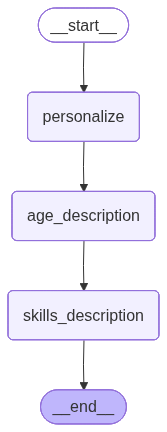

In [15]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [17]:
result = app.invoke({"name": "Alice", "age": "30", "skills": ["Python", "Data Analysis"]})

In [18]:
result["final"]

'Alice, welcome to the system! You are 30 years old. You have skills in: Python, Data Analysis'